In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch

import os
from pathlib import Path
import pickle

from collections import defaultdict
from wordfreq import word_frequency, zipf_frequency


In [2]:
df = []
langs = {0: 'en', 2: 'ru'}
for i,pth in enumerate([
    r'../../datasets/se10/en/semeval10.tsv',
    # r'../../datasets/xl_wsd/en/dev.tsv',
    # r'../../datasets/russe_bts-rnc/ru/train.tsv',
]):
    t = pd.read_csv(pth, sep='\t')
    if i in langs:
        t['lang'] = langs[i]
    df.append(t)
df = pd.concat(df)
df['pos_tag'] = df.gold_sense_id.apply(lambda x: 'n' if '.n.' in x else 'v')
df

,context_id,word,gold_sense_id,predict_sense_id,positions,context,lang,pos_tag
0,display.n.1,display,display.n.1,NaN,107-114,"In a corner of the cavernous, new Nippon Conve...",en,n
1,display.n.2,display,display.n.1,NaN,213-220,"With the touch of a button, drivers can choose...",en,n
2,display.n.3,display,display.n.1,NaN,169-176,Suzuki Motor Co. 's Escudome sport vehicle fea...,en,n
3,display.n.4,display,display.n.1,NaN,27-35,New Technology The hottest displays were items...,en,n
4,display.n.5,display,display.n.1,NaN,136-144,"By contrast, the pistons in conventional four ...",en,n
...,...,...,...,...,...,...,...,...
8910,reveal.v.122,reveal,reveal.v.1,NaN,100-106,"-LRB- facing page -RRB- After 40, temples star...",en,v
8911,reveal.v.123,reveal,reveal.v.1,NaN,234-241,"As the forestry industry gradually declined, t...",en,v
8912,reveal.v.124,reveal,reveal.v.2,NaN,172-180,"Gao refers to his own approach to writing as ""...",en,v
8913,reveal.v.125,reveal,reveal.v.2,NaN,292-300,"Weighing only about 40 kilos, Law looks light ...",en,v


In [3]:
stats = pd.DataFrame(df.groupby('word')['gold_sense_id'].apply(lambda x: '/'.join([str(t) for t in sorted(x.value_counts(), reverse=True)])))
stats['sense_count_ratio_avg'] = df.groupby('word')['gold_sense_id'].apply(lambda x: np.mean([t1/t2 for t1,t2 in zip(
    [t for t in sorted(x.value_counts(), reverse=True)][1:],
    [t for t in sorted(x.value_counts(), reverse=True)][:-1]
)]))

stats['ratio12'] = stats['gold_sense_id'].apply(lambda x: int(x.split('/')[0]) / int(x.split('/')[1]))
stats['sense_count'] = stats['gold_sense_id'].apply(lambda x: 1 + x.count('/'))
stats['lang'] = df.groupby('word').lang.first()
stats['context_len'] = df.groupby('word')['context'].apply(lambda x: x.apply(len).mean())
stats['example_count'] = df.groupby('word')['context'].count()
stats['avg_examples_per_sense'] = stats['example_count'] / stats['sense_count']

stats['wordfreq'] = [zipf_frequency(t, stats['lang'].loc[t]) for t in stats.index]

output_dir = Path('../../outputs/2023-09-12_20-26-27')
for word in stats.index:
    word_metrics = pd.read_csv(output_dir / 'VectorizingPipeline' / 'word_metrics' / (word + '.tsv'), sep='\t')
    for best_by in ['ARI', 'calinski_harabasz']:
        stats.loc[word, 'max_' + best_by] = word_metrics.loc[word_metrics[best_by] == word_metrics[best_by].max(), best_by].iloc[0]
        stats.loc[word, best_by + '_' + "ARI"] = word_metrics.loc[word_metrics[best_by] == word_metrics[best_by].max(), 'ARI'].iloc[0]
        stats.loc[word, best_by + '_' + 'sysClusterNum'] = word_metrics.loc[word_metrics[best_by] == word_metrics[best_by].max(), 'sysClusterNum'].iloc[0]
stats


FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/2023-09-12_20-26-27/VectorizingPipeline/word_metrics/access.tsv'

In [6]:
stats[stats.lang == 'sl']

,gold_sense_id,sense_count_ratio_avg,ratio12,sense_count,lang,context_len,example_count,avg_examples_per_sense,wordfreq,max_ARI,ARI_ARI,ARI_sysClusterNum,max_calinski_harabasz,calinski_harabasz_ARI,calinski_harabasz_sysClusterNum
word,,,,,,,,,,,,,,,
beseda,13/13/3/1,0.521368,1.000000,4,sl,125.966667,30,7.500000,4.89,63.323763,63.323763,4.0,1.890590,52.220904,3.0
denar,26/7/1,0.206044,3.714286,3,sl,108.705882,34,11.333333,5.09,1.057086,1.057086,9.0,1.588930,-12.513430,2.0
država,29/13/8,0.531830,2.230769,3,sl,151.100000,50,16.666667,5.16,18.550532,18.550532,3.0,1.932971,18.550532,3.0
hiša,42/1/1,0.511905,42.000000,3,sl,115.136364,44,14.666667,5.05,65.079365,65.079365,2.0,1.323173,11.677759,8.0
mesto,11/7/5/3/1/1,0.656797,1.571429,6,sl,113.928571,28,4.666667,5.79,38.192653,38.192653,6.0,1.367207,13.940161,2.0
moč,10/4/3/2,0.605556,2.500000,4,sl,162.105263,19,4.750000,5.29,9.258920,9.258920,8.0,1.346119,-5.180979,2.0
način,18/3/1,0.250000,6.000000,3,sl,143.318182,22,7.333333,5.52,8.382910,8.382910,8.0,1.431082,2.426976,3.0
okolje,11/6/2,0.439394,1.833333,3,sl,177.631579,19,6.333333,4.91,59.127577,59.127577,6.0,1.317976,32.837705,3.0
prostor,10/7/2/1/1,0.621429,1.428571,5,sl,173.238095,21,4.200000,5.23,37.564322,37.564322,8.0,1.500887,11.617712,3.0


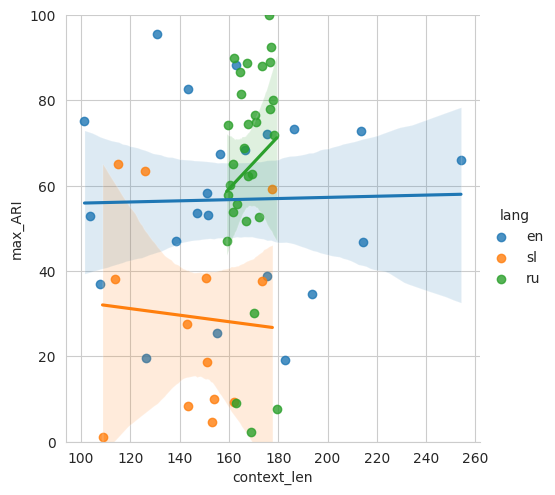

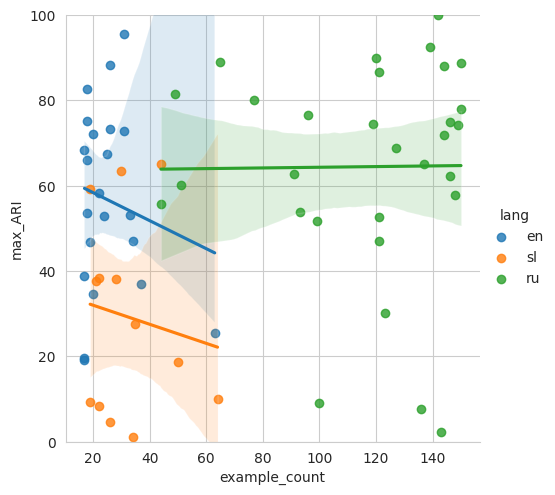

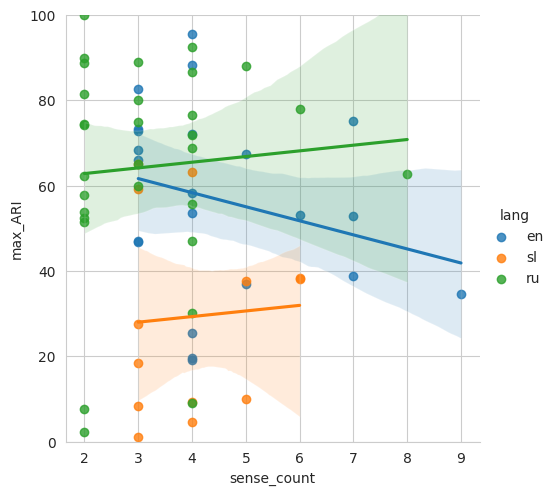

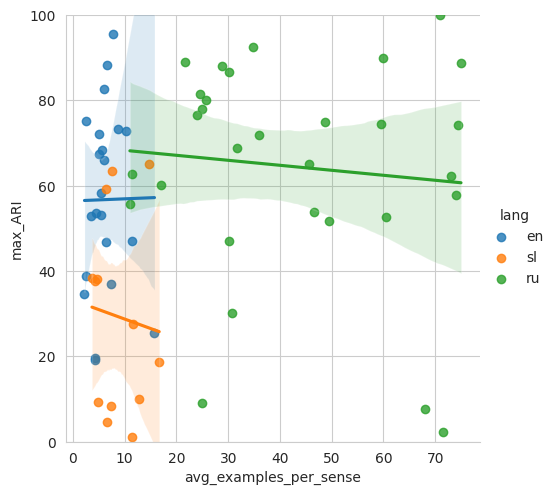

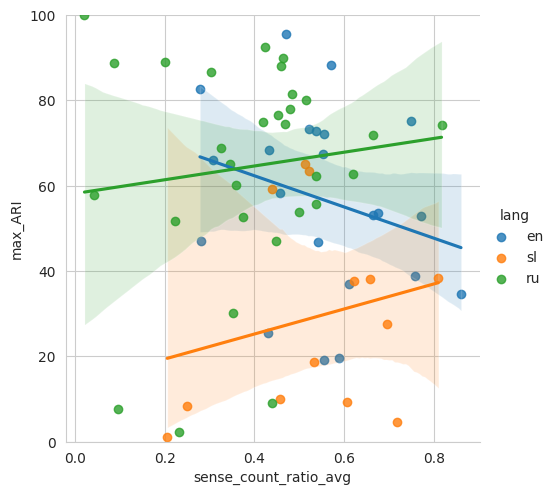

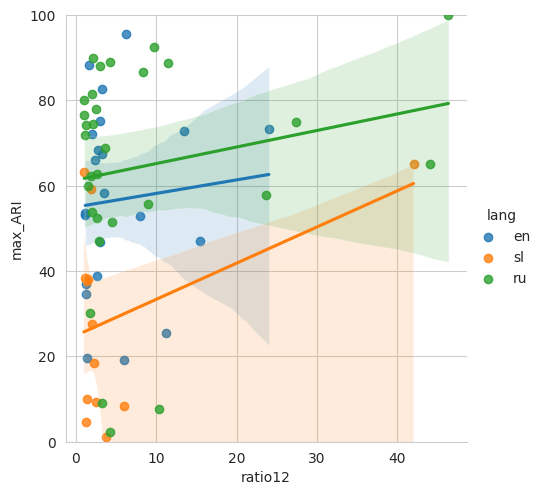

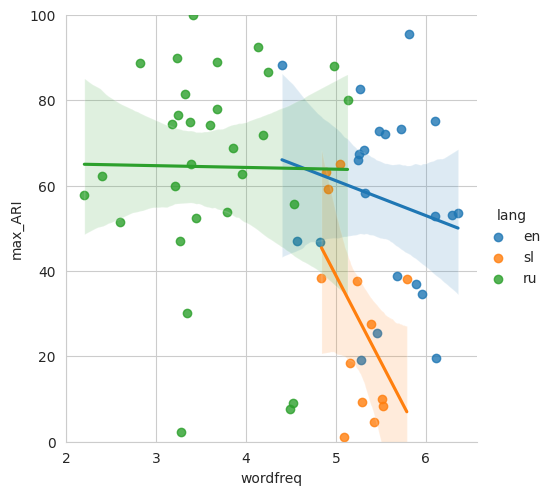

In [7]:
for i, stat in enumerate(['context_len', 'example_count', 'sense_count', 'avg_examples_per_sense', 'sense_count_ratio_avg' , 'ratio12', 'wordfreq']):
    sns.lmplot(data=stats, x=stat, y='max_ARI', hue='lang')
    plt.ylim(0, 100)

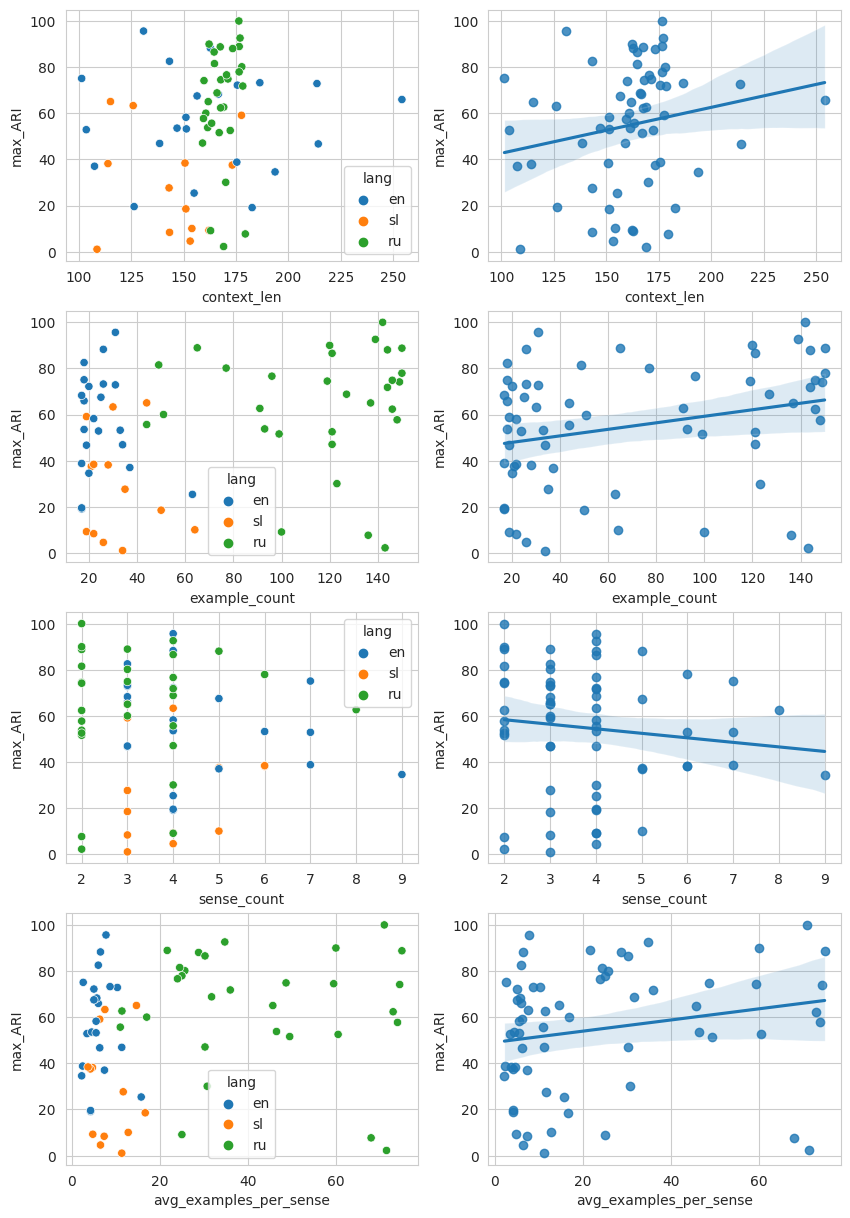

In [9]:

fig, ax = plt.subplots(4, 2, figsize=(10, 15))
for i, stat in enumerate(['context_len', 'example_count', 'sense_count', 'avg_examples_per_sense']):
    sns.scatterplot(data=stats, x=stat, y='max_ARI', hue='lang', ax=ax[i][0])
    sns.regplot(data=stats, x=stat, y='max_ARI', ax=ax[i][1])

Using cache found in /home/deniskokosss/.cache/torch/hub/pytorch_fairseq_main
2023-10-17 18:32:08 | INFO | root | running build_ext
/home/deniskokosss/miniconda3/envs/summer-wsi/lib/python3.9/site-packages/torch/utils/cpp_extension.py:476: UserWarning: Attempted to use ninja as the BuildExtension backend but we could not find ninja.. Falling back to using the slow distutils backend.
  warnings.warn(msg.format('we could not find ninja.'))
2023-10-17 18:32:08 | INFO | root | skipping 'fairseq/data/data_utils_fast.cpp' Cython extension (up-to-date)
2023-10-17 18:32:08 | INFO | root | skipping 'fairseq/data/token_block_utils_fast.cpp' Cython extension (up-to-date)
2023-10-17 18:32:08 | INFO | root | building 'fairseq.libbleu' extension
2023-10-17 18:32:08 | INFO | root | creating build/temp.linux-x86_64-cpython-39
2023-10-17 18:32:08 | INFO | root | creating build/temp.linux-x86_64-cpython-39/fairseq
2023-10-17 18:32:08 | INFO | root | creating build/temp.linux-x86_64-cpython-39/fairseq/cl

'▁my ▁name ▁is ▁gi ovan ni ▁gi ori gio'

In [41]:
df

,context_id,word,gold_sense_id,predict_sense_id,positions,context,lang
0,0,връзка,bn:00001755n,NaN,10-16,специална връзка.,bg
1,1,връзка,bn:00001755n,NaN,10-16,поддържам връзка с.,bg
2,2,връзка,bn:00002860n,NaN,14-20,професионална връзка.,bg
3,3,връзка,bn:00013883n,NaN,0-6,връзка с ключове.,bg
4,4,връзка,bn:00021901n,NaN,29-35,Тези проблеми са във взаимна връзка.,bg
...,...,...,...,...,...,...,...
733,1470,človek,bn:00061450n,NaN,197-203,"» Naši pogledi na lepoto, « pojasnjuje Emmanue...",sl
734,1471,človek,bn:00061450n,NaN,25-31,Po hodnikih so že hodili ljudje in se pogovarj...,sl
735,1472,človek,bn:00061450n,NaN,15-21,"Se ne bi mogli ljudje v medijih, pisatelji, go...",sl
736,1473,človek,bn:00061450n,NaN,21-27,"In Resnica, ki so jo ljudje začeli kupovati, n...",sl


In [23]:
res = []
for word in stats.index:
    word_df = df[df.word == word]
    sense_counts = word_df['gold_sense_id'].value_counts()
    global_word_probs = defaultdict(int)
    local_word_probs = {k: defaultdict(int) for k in word_df['gold_sense_id'].unique()}
    with open(output_dir / 'substs' / (word + '.pkl'), 'rb') as f:
        scores, word2id = pickle.load(f)
        id2word = {v:k for k,v in word2id.items()}
    for i in range(len(scores)):
        top_k = np.where(scores[i] > 0)[0]
        for idx in top_k:
            global_word_probs[id2word[idx]] += 1
            local_word_probs[word_df['gold_sense_id'].iloc[i]][id2word[idx]] += 1
    global_probs = pd.Series(global_word_probs)
    for sense in local_word_probs:
        local_probs = pd.Series(local_word_probs[sense])
        diff_probs = local_probs / (global_probs[local_probs.index] - local_probs).clip(1.0)
        top_k_substs = diff_probs.nlargest(5)
        df_res = pd.concat([top_k_substs, local_probs[top_k_substs.index], global_probs[top_k_substs.index] - local_probs[top_k_substs.index]], axis=1)
        df_res.columns = ['diff', 'local', 'global']
        df_res['sense'] = sense
        df_res['target_word'] = word
        df_res['n'] = sense_counts[sense]
        res.append(df_res)
subst_df = pd.concat(res).sort_values(by=['target_word', 'diff'], ascending=False)
subst_df

,diff,local,global,sense,target_word,n
стереотип,40.0,40,1,4,штамп,47
идея,29.0,29,1,4,штамп,47
удостоверение,26.0,26,1,1,штамп,45
игра,26.0,26,0,4,штамп,47
термин,26.0,26,1,4,штамп,47
...,...,...,...,...,...,...
abandonment,1.0,1,0,bn:00001128n,action,1
abduction,1.0,1,0,bn:00001128n,action,1
adherence,1.0,1,0,bn:00001128n,action,1
aggression,1.0,1,1,bn:00001128n,action,1


In [22]:
def build_subst_report(df0):
    res = [f"{df0['target_word'].iloc[0]}[{df0['n'].iloc[0]}rows]"]
    for idx, row in df0.iterrows():
        res.append(f"{idx}[{tokenizer.encode(idx).count(' ') + 1}t] ({int(row['local'])}/{int(row['global'])})")
    res.append(df.loc[(df.word == df0.target_word.iloc[0]) & (df.gold_sense_id == df0.sense.iloc[0]), 'context'].iloc[0])
    return res

discriminative_substs = pd.DataFrame(subst_df.groupby(['target_word', 'sense']).apply(build_subst_report).tolist())
discriminative_substs.columns = ['target', 'top1', 'top2', 'top3', 'top4', 'top5', 'context_example']
discriminative_substs

,target,top1,top2,top3,top4,top5,context_example
0,action[12rows],behavior[1t] (12/1),behaviour[1t] (10/1),claim[1t] (9/1),mistake[1t] (9/1),conduct[1t] (9/1),"Ricardo Ulate, a Costa Rican delegate, said it..."
1,action[1rows],abandonment[2t] (1/1),abduction[2t] (1/0),access[1t] (1/0),accident[1t] (1/1),actionin[2t] (1/0),"The marine environment, which covers almost 70..."
2,action[5rows],initiative[1t] (5/0),leadership[1t] (5/1),concern[1t] (4/1),economic[1t] (4/1),government[1t] (4/1),1 -RRB- Voters can ``buy`` one of two brands w...
3,area[5rows],load[1t] (3/1),30[1t] (2/1),humidity[2t] (2/0),arable[2t] (2/0),name[1t] (2/1),Areas that are made of `fill 'liquefy.
4,area[1rows],AFC[2t] (1/0),League[1t] (1/0),MLS[2t] (1/0),NBA[1t] (1/0),NFL[1t] (1/0),"The Ticos players, however, have a limited int..."
...,...,...,...,...,...,...,...
242,хвост[1rows],adder[2t] (1/0),ballet[2t] (1/1),baseball[1t] (1/0),boss[1t] (1/0),bot[1t] (1/0),"работать, то решать семейные проблемы. Часто б..."
243,штамп[45rows],check[1t] (33/0),passport[2t] (28/1),bar[1t] (27/1),inscription[2t] (23/1),mention[1t] (23/0),я был депортирован во время Оранжевой революци...
244,штамп[1rows],actual[1t] (1/1),ch[1t] (1/0),complete[1t] (1/0),compression[2t] (1/0),contraction[2t] (1/0),внутренних дел в паспорте гражданина РФ на стр...
245,штамп[3rows],ball[1t] (2/0),binder[2t] (2/1),boiler[2t] (2/0),casting[1t] (2/0),chamber[2t] (2/0),такого стекла очень проста. Еще не затвердевшу...


In [ ]:
tokenizer = torch.hub.load('pytorch/fairseq', 'xlmr.large').bpe
tokenizer.encode("my name is giovanni giorigio")

In [59]:
ans = []

for c in zip([
    "../../outputs/2023-10-19_10-45-41/+runname=discs,model_vec=lexsubgen",
    '../../outputs/2023-10-19_10-45-41/+runname=discs,model_vec=subst_123_or_even',
    "../../outputs/2023-10-19_10-45-41/+runname=discs,model_vec=subst_cwm_ru_v2_and_also"
], ['+embs', '"or even"', 'WCM ru "and also"']):
    output_dir = Path(c[0])
    model_name = c[1]

    stats = pd.DataFrame(df.groupby('word')['gold_sense_id'].apply(lambda x: '/'.join([str(t) for t in sorted(x.value_counts(), reverse=True)])))
    stats['sense_count_ratio_avg'] = df.groupby('word')['gold_sense_id'].apply(lambda x: np.mean([t1/t2 for t1,t2 in zip(
        [t for t in sorted(x.value_counts(), reverse=True)][1:],
        [t for t in sorted(x.value_counts(), reverse=True)][:-1]
    )]))
    stats['sense_count'] = stats['gold_sense_id'].apply(lambda x: 1 + x.count('/'))
    stats['lang'] = df.groupby('word').lang.first()
    stats['context_len'] = df.groupby('word')['context'].apply(lambda x: x.apply(len).mean())
    stats['example_count'] = df.groupby('word')['context'].count()
    stats['avg_examples_per_sense'] = stats['example_count'] / stats['sense_count']
    for word in stats.index:
        if '+embs' in model_name:
            word_metrics = pd.read_csv(output_dir / 'LexSubGenAdapter' / 'word_metrics' / (word + '.tsv'), sep='\t')
        else:
            word_metrics = pd.read_csv(output_dir / 'VectorizingPipeline' / 'word_metrics' / (word + '.tsv'), sep='\t')
        for best_by in ['ARI', 'calinski_harabasz']:
            stats.loc[word, 'max_' + best_by] = word_metrics.loc[word_metrics[best_by] == word_metrics[best_by].max(), best_by].iloc[0]
            stats.loc[word, best_by + '_' + "ARI"] = word_metrics.loc[word_metrics[best_by] == word_metrics[best_by].max(), 'ARI'].iloc[0]
            stats.loc[word, best_by + '_' + 'sysClusterNum'] = word_metrics.loc[word_metrics[best_by] == word_metrics[best_by].max(), 'sysClusterNum'].iloc[0]
    res = []
    for word in stats.index:
        word_df = df[df.word == word]
        sense_counts = word_df['gold_sense_id'].value_counts()
        global_word_probs = defaultdict(int)
        local_word_probs = {k: defaultdict(int) for k in word_df['gold_sense_id'].unique()}
        with open(output_dir / 'substs' / (word + '.pkl'), 'rb') as f:
            scores, word2id = pickle.load(f)
            id2word = {v:k for k,v in word2id.items()}
        for i in range(len(scores)):
            top_k = np.where(scores[i] > 0)[0]
            for idx in top_k:
                global_word_probs[id2word[idx]] += 1
                local_word_probs[word_df['gold_sense_id'].iloc[i]][id2word[idx]] += 1
        global_probs = pd.Series(global_word_probs)
        for sense in local_word_probs:
            local_probs = pd.Series(local_word_probs[sense])
            diff_probs = local_probs / (global_probs[local_probs.index] - local_probs).clip(1.0)
            top_k_substs = diff_probs.nlargest(3)
            df_res = pd.concat([top_k_substs, local_probs[top_k_substs.index], global_probs[top_k_substs.index] - local_probs[top_k_substs.index]], axis=1)
            df_res.columns = ['diff', 'local', 'global']
            df_res['sense'] = sense
            df_res['target_word'] = word
            df_res['n'] = sense_counts[sense]
            res.append(df_res)
    subst_df = pd.concat(res).sort_values(by=['target_word', 'diff'], ascending=False)
    def build_subst_report(df0):
        res = [f"{df0['target_word'].iloc[0]} \\\\ ({df0['n'].iloc[0]} instances)"]
        for idx, row in df0.iterrows():
            res.append(f"{idx}") #  ([{tokenizer.encode(idx).count(' ') + 1}t] {int(row['local'])}/{int(row['global'])})
        res.append(df.loc[(df.word == df0.target_word.iloc[0]) & (df.gold_sense_id == df0.sense.iloc[0]), 'context'].iloc[0])
        return res

    discriminative_substs = pd.DataFrame(subst_df.groupby(['target_word', 'sense']).apply(build_subst_report).tolist())
    discriminative_substs.columns = ['target', 'top1',
                                     'top2', 'top3',
                                     # 'top4', 'top5',
                                     # 'top6', 'top7', 'top8', 'top9', 'top10',
                                     # 'top11', 'top12', 'top13', 'top14', 'top15',
                                     # 'top16', 'top17', 'top18', 'top19', 'top20',
                                     'context_example']
    t = discriminative_substs.copy()
# 221, 222, 231, 232, 259, 260, 292 , 295
#     good_idx = [t for t in [0, 2, 14, 16, 21, 23, 32, 33, 65, 66, 116, 119, 236,238, 214,215,216, 170,173]]
    good_idx = [36, 37, 38, 54, 58, 111, 114]
    discriminative_substs = discriminative_substs.loc[good_idx, :].melt(id_vars=['target', 'context_example']).set_index(['target', 'context_example', 'variable']).rename(columns={'value': model_name})
    ans.append(discriminative_substs)

In [52]:
t

,target,top1,top2,top3,context_example
0,access \\ (19 instances),интернет[1t] (7/1),подтвердить[4t] (6/1),список[1t] (6/1),The problems were uncovered during a series of...
1,access \\ (17 instances),лекарство[1t] (6/1),прав[1t] (6/0),предпостить[3t] (6/0),Michigan's Senate passed a bill requiring girl...
2,access \\ (9 instances),граница[1t] (5/1),перевозка[3t] (5/1),подъезд[2t] (5/1),"The port is famous for wind shelter, deep wate..."
3,access \\ (3 instances),двигать[3t] (3/1),ночь[1t] (3/0),проникнуть[2t] (3/1),Saturday night she dined in an emergency shelt...
4,accommodate \\ (6 instances),соблазн[4t] (5/0),менять[2t] (4/1),уважить[3t] (4/1),They would allow him to buy even more U.S. tel...
...,...,...,...,...,...
380,weigh \\ (1 instances),MРТ[2t] (1/0),checking[1t] (1/1),examineяя[3t] (1/0),"During this first breeding session, for fear o..."
381,weigh \\ (7 instances),рассматривать[1t] (7/1),опредовить[4t] (5/1),рассматрить[3t] (5/1),"I'm David Coler, VOA News. Three Florida court..."
382,weigh \\ (4 instances),5050[2t] (3/0),временный[2t] (3/0),25[1t] (2/0),[Charlie_Cook] I mean your ~NBC Wall Street Jo...
383,weigh \\ (2 instances),42[1t] (2/0),бросить[2t] (2/1),веснять[2t] (2/0),"On April 17, 1610, the sturdy little three-mas..."


In [13]:
pd.concat(ans, axis=1).reset_index().sort_values(by=['target', 'context_example', 'variable'])

,target,context_example,variable,"concat ""or even""","WCM en ""or even""","WCM RU ""and also""","WCM multi ""and also""",CONCAT+embs
0,action \\ (12 instances),"Ricardo Ulate, a Costa Rican delegate, said it...",top1,behavior[1t] (12/1),behavior[1t] (12/1),правило[1t] (12/1),deliberation[2t] (10/1),behavior[1t] (9/0)
19,action \\ (12 instances),"Ricardo Ulate, a Costa Rican delegate, said it...",top2,practice[1t] (12/1),behaviour[1t] (10/1),поведение[1t] (10/0),rule[1t] (10/1),practice[1t] (8/0)
38,action \\ (12 instances),"Ricardo Ulate, a Costa Rican delegate, said it...",top3,intention[1t] (11/1),claim[1t] (9/1),ситуация[1t] (10/0),its[1t] (9/0),behaviour[1t] (6/0)
1,action \\ (5 instances),1 -RRB- Voters can ``buy`` one of two brands w...,top1,legislation[2t] (4/1),initiative[1t] (5/0),деньги[1t] (4/1),financial[1t] (5/0),initiative[1t] (3/0)
20,action \\ (5 instances),1 -RRB- Voters can ``buy`` one of two brands w...,top2,negotiation[3t] (4/1),leadership[1t] (5/1),финансовый[2t] (4/1),government[1t] (5/1),accountability[2t] (2/0)
39,action \\ (5 instances),1 -RRB- Voters can ``buy`` one of two brands w...,top3,opposite[1t] (4/1),concern[1t] (4/1),политический[2t] (3/0),measure[1t] (5/1),control[1t] (2/0)
3,case \\ (12 instances),"For decades, appeals courts have recognized th...",top1,court[1t] (12/1),charge[1t] (12/1),свой[1t] (11/0),court[1t] (12/1),lawsuit[2t] (10/0)
22,case \\ (12 instances),"For decades, appeals courts have recognized th...",top2,law[1t] (12/0),action[1t] (11/0),процесс[1t] (10/1),action[1t] (11/0),trial[1t] (8/1)
41,case \\ (12 instances),"For decades, appeals courts have recognized th...",top3,charge[1t] (11/0),trial[1t] (11/0),решение[1t] (10/1),trial[1t] (10/1),decision[1t] (7/0)
2,case \\ (6 instances),It often is preceded by the development of pol...,top1,almost[1t] (4/0),extreme[1t] (4/0),вид[1t] (5/1),form[1t] (5/1),form[1t] (4/0)


In [15]:
pd.concat(ans, axis=1).reset_index().sort_values(by=['target', 'context_example', 'variable']).set_index(['context_example', 'target']).drop(columns='variable')

concat "or even"  \
context_example                                    target                                                
Ricardo Ulate, a Costa Rican delegate, said it'... action \\ (12 instances)        behavior[1t] (12/1)   
                                                   action \\ (12 instances)        practice[1t] (12/1)   
                                                   action \\ (12 instances)       intention[1t] (11/1)   
1 -RRB- Voters can ``buy`` one of two brands wh... action \\ (5 instances)       legislation[2t] (4/1)   
                                                   action \\ (5 instances)       negotiation[3t] (4/1)   
                                                   action \\ (5 instances)          opposite[1t] (4/1)   
For decades, appeals courts have recognized tha... case \\ (12 instances)             court[1t] (12/1)   
                                                   case \\ (12 instances)               law[1t] (12/0)   
                                                   case \\ (12 instances)            charge[1t] (11/0)   
It often is preceded by the development of poly... case \\ (6 instances)              almost[1t] (4/0)   
                                                   case \\ (6 instances)                 and[1t] (4/1)   
                                                   case \\ (6 instances)              degree[1t] (4/0)   
Nature development in the Netherlands has alrea... decline \\ (15 instances)           loss[1t] (15/0)   
                                                   decline \\ (15 instances)     stagnation[2t] (14/0)   
                                                   decline \\ (15 instances)         growth[1t] (14/0)   
The number of species is still declining, altho... decline \\ (9 instances)           expand[1t] (9/1)   
                                                   decline \\ (9 instances)             melt[2t] (8/1)   
                                                   decline \\ (9 instances)          recover[1t] (8/1)   
Država potemtakem mora uvesti nove davke, če ho... država \\ (13 instances)              MOL[1t] (6/1)   
                                                   država \\ (13 instances)          narava[2t] (10/2)   
                                                   država \\ (13 instances)            odbor[1t] (5/1)   
Zaporniki, med katerimi so tudi » teroristi « i... država \\ (29 instances)            član[1t] (12/0)   
                                                   država \\ (29 instances)             oba[1t] (10/1)   
                                                   država \\ (29 instances)        številen[2t] (10/0)   
Vseeno pa zavedanje njene moči, sposobnosti, da... moč \\ (10 instances)              korist[1t] (8/1)   
                                                   moč \\ (10 instances)              oblast[1t] (7/0)   
                                                   moč \\ (10 instances)               vloga[2t] (7/0)   
HKRATI SE ZAČUDI NAD SVOJO PRISEBNOSTJO IN FIZI... moč \\ (4 instances)                nekaj[1t] (2/0)   
                                                   moč \\ (4 instances)              tehnika[1t] (2/1)   
                                                   moč \\ (4 instances)                barva[1t] (2/1)   
V zadnjih treh letih je Real dobil namreč kar n... svet \\ (21 instances)             mogoč[1t] (12/1)   
                                                   svet \\ (21 instances)           Japonsko[2t] (9/1)   
                                                   svet \\ (21 instances)            Floridi[2t] (8/0)   
Glas Haberlove stopi na opustošeno obalo, v opu... svet \\ (30 instances)             Srbija[1t] (9/1)   
                                                   svet \\ (30 instances)               tema[1t] (8/1)   
                                                   svet \\ (30 instances)                SLO[2t] (8/1)   
селам и весям российским -- прошлогодней листво... клетка 

In [60]:
print(pd.concat(ans, axis=1).reset_index().sort_values(by=['target', 'context_example', 'variable']).set_index(['context_example', 'target']).drop(columns='variable').style.to_latex(multirow_align='t'))

\begin{tabular}{lllll}
 &  & +embs & "or even" & WCM ru "and also" \\
context_example & target &  &  &  \\
\multirow[t]{3}{*}{Xinhua News Agency, Beijing, August 31st, by reporter Siyi Ni The Standing Committee of the National People's Congress, which is the highest legislative body of China, passed a resolution today that when sovereignty over Hong Kong is regained in 1997, China will re-organize Hong Kong's legislative body and regional organization. The 127 members attending the 9th meeting of the 8th National People's Congress, which closed today, passed this resolution with all affirmative votes.} & body \\ (33 instances) & institution & organization & чиновник \\
 & body \\ (33 instances) & govern & committee & учреждение \\
 & body \\ (33 instances) & organization & office & государство \\
\multirow[t]{3}{*}{This kind of drug can slowly discharge the mold element from the cells of plants in water. When mosquitoes feed, they suck the mold element from the cells of plants into the

In [8]:
t

,target,top1,top2,top3,context_example
0,action[12rows],behavior[1t] (9/0),practice[1t] (8/0),behaviour[1t] (6/0),"Ricardo Ulate, a Costa Rican delegate, said it..."
1,action[1rows],activism[2t] (1/0),aggression[2t] (1/0),development[1t] (1/0),"The marine environment, which covers almost 70..."
2,action[5rows],initiative[1t] (3/0),accountability[2t] (2/0),control[1t] (2/0),1 -RRB- Voters can ``buy`` one of two brands w...
3,area[5rows],plant[1t] (2/1),catchment[2t] (2/0),vegetation[2t] (3/2),Areas that are made of `fill 'liquefy.
4,area[1rows],academy[3t] (1/0),arena[1t] (1/0),association[1t] (1/0),"The Ticos players, however, have a limited int..."
...,...,...,...,...,...
242,хвост[1rows],10[1t] (1/1),11[1t] (1/1),12[1t] (1/1),"работать, то решать семейные проблемы. Часто б..."
243,штамп[45rows],надпись[2t] (20/0),печать[2t] (28/2),запись[2t] (14/0),я был депортирован во время Оранжевой революци...
244,штамп[1rows],бланка[2t] (1/0),гербовый[2t] (1/0),ключ[1t] (1/0),внутренних дел в паспорте гражданина РФ на стр...
245,штамп[3rows],аппарат[1t] (2/0),машина[1t] (2/0),пресса[2t] (2/1),такого стекла очень проста. Еще не затвердевшу...


In [39]:
import json
from nltk.tokenize import word_tokenize

substs = json.load(open(r"../../.cache/xlmr123_embs_0.07.json", 'r'))
{k:v for k,v in substs.items() if k.startswith('_10_')}

{'_10_• Тряпочка • Пила • Сверло диаметром 3 мм • Винты такого же диаметра • Кисточки ( широкая и узкая ) КАК ЭТО ДЕЛАЕТСЯ Если в': ['сверло ключ лист нож инструмент шар кисточка заготовка саморезы колесо все головка ручка вал Саморез крепление провод лук гайка ось ремень отвёртка стопор звезда макароны шип краска блок кронштейн коробка крышка вилка камень палец кисть бумага свеча кулон голова болт макар трубка корпус насадка тормоза щётка зуб только элемент основа клеток дерево мастер вот оружие бас вектор фрезер фреза катушка стекло шаблон вес прокладка Точно цилиндр угол пластик хомут туфля барабан два маска про резка пара кромка мыло щепки куб шейка шифер мойка ножик бак шнур форма перчатка опора мост ру гриб колба вырез даже пила прутки шприц перо бисер рамка замок пятка метка кабель сабли материал набор молот ковёр кристалл Всё брусочек дуб бутылка бен ложка мотор сталь бра лента пол доска пучок рез груз сетка или три стрелка цинк но мел рот прес главный сопло щатки винтовка гар 

In [40]:
word2id = {}
def parse_context(row):
    begin_idx, end_idx = map(int, row['positions'].split('-'))
    tokens = word_tokenize(row['context'])
    word = row['context'][begin_idx:end_idx]
    poss = [i for i,t in enumerate(tokens) if word in t]
    poss = [i-1 for i in poss] + poss + [i+1 for i in poss]
    for pos in poss:
        cache_key = f'_{pos}_' + ' '.join(tokens)
        if cache_key in substs:
            s = substs[cache_key][0].split(' ')[:20]
            return " ".join(s)
    return " ".join([f'!!!{i}' for i in range(20)])

from sklearn.feature_extraction.text import TfidfVectorizer



In [41]:
import pickle
for word, word_df in df.groupby('word'):
    vect = TfidfVectorizer()
    vectors = vect.fit_transform(word_df.apply(parse_context, axis=1)).toarray()
    scores, word2id = vectors, vect.vocabulary_
    with open(f'../../outputs/2023-10-19_10-45-41/+runname=discs,model_vec=lexsubgen/substs/{word}.pkl', 'wb') as f:
        pickle.dump((scores, word2id), f)

In [42]:
vectors

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [84]:
df

,context_id,word,gold_sense_id,predict_sense_id,positions,context,lang
0,677,beseda,bn:00069438n,NaN,9-15,Hvala za besedo.,sl
1,678,beseda,bn:00069438n,NaN,12-18,Želi še kdo besedo?,sl
2,679,beseda,bn:00069438n,NaN,22-28,"Ker nihče ne želi več besede, zaključujem razp...",sl
3,680,beseda,bn:00074033n,NaN,131-137,"Morda se jim nič od tega, kar je povedal, ni z...",sl
4,681,beseda,bn:00074033n,NaN,95-103,"Ministrstvu za okolje, prostor in energijo so ...",sl
...,...,...,...,...,...,...,...
3486,3487,штамп,4,NaN,81-87,"дурак, но партию свою отрабатывал точно, по ус...",ru
3487,3488,штамп,4,NaN,85-91,"дело... получается, мыслить и выражать свое мн...",ru
3488,3489,штамп,4,NaN,71-78,", что актер должен иметь пять штампов-клише ""п...",ru
3489,3490,штамп,4,NaN,107-113,сегодняшний день в системе негосударственного ...,ru


In [80]:
vectors

matrix([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.24316473, 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]])

In [83]:
vect.vocabulary_

{'документ': 93,
 'номер': 280,
 'паспорт': 336,
 'адрес': 1,
 'полис': 365,
 'прочерк': 420,
 'штампа': 648,
 'код': 181,
 'дубликат': 96,
 'знак': 129,
 'пункт': 422,
 'мне': 236,
 'лист': 207,
 'печать': 345,
 'регистрационный': 442,
 'бланк': 15,
 'штрих': 652,
 'чек': 629,
 'пропуск': 416,
 'трафарет': 571,
 'надпись': 250,
 'слово': 483,
 'буква': 24,
 'наклейка': 254,
 'полоса': 368,
 'рисунок': 448,
 'картинка': 167,
 'цифра': 626,
 'контур': 190,
 'розочками': 452,
 'глаз': 62,
 'пометками': 371,
 'вставка': 49,
 'листочек': 210,
 'узор': 585,
 'табличка': 543,
 'цвет': 621,
 'лицо': 211,
 'знакомый': 130,
 'название': 251,
 'подпись': 360,
 'указание': 587,
 'рука': 457,
 'отметка': 324,
 'орган': 311,
 'копия': 193,
 'удостоверение': 582,
 'акт': 2,
 'печат': 344,
 'деньга': 82,
 'договор': 91,
 'текст': 553,
 'заголовок': 111,
 'пометка': 369,
 'уведомитель': 579,
 'маркер': 220,
 'обозначение': 290,
 'приписка': 401,
 'формулировка': 609,
 'девиз': 77,
 'ярлык': 667,
 'ста

In [48]:
ans = []
for c in zip([
    "../../outputs/2023-10-19_10-45-41/+runname=discs,model_vec=lexsubgen",
    '../../outputs/2023-10-19_10-45-41/+runname=discs,model_vec=subst_123_or_even',
    # "../../outputs/2023-10-19_10-45-41/+runname=discs,model_vec=subst_cwm_ru_v2_and_also"
], ['+embs', '"or even"', 'WCM ru "and also"']):
    output_dir = Path(c[0])
    model_name = c[1]

    stats = pd.DataFrame(df[df.pos_tag == 'n'].groupby('word')['gold_sense_id'].apply(lambda x: '/'.join([str(t) for t in sorted(x.value_counts(), reverse=True)])))
    stats['sense_count_ratio_avg'] = df.groupby('word')['gold_sense_id'].apply(lambda x: np.mean([t1/t2 for t1,t2 in zip(
        [t for t in sorted(x.value_counts(), reverse=True)][1:],
        [t for t in sorted(x.value_counts(), reverse=True)][:-1]
    )]))
    stats['sense_count'] = stats['gold_sense_id'].apply(lambda x: 1 + x.count('/'))
    stats['lang'] = df.groupby('word').lang.first()
    stats['context_len'] = df.groupby('word')['context'].apply(lambda x: x.apply(len).mean())
    stats['example_count'] = df.groupby('word')['context'].count()
    stats['avg_examples_per_sense'] = stats['example_count'] / stats['sense_count']
    for word in stats.index:
        if '+embs' in model_name:
            word_metrics = pd.read_csv(output_dir / 'LexSubGenAdapter' / 'word_metrics' / (word + '.tsv'), sep='\t')
        else:
            word_metrics = pd.read_csv(output_dir / 'VectorizingPipeline' / 'word_metrics' / (word + '.tsv'), sep='\t')
        for best_by in ['ARI', 'calinski_harabasz']:
            stats.loc[word, 'max_' + best_by] = word_metrics.loc[word_metrics[best_by] == word_metrics[best_by].max(), best_by].iloc[0]
            stats.loc[word, best_by + '_' + "ARI"] = word_metrics.loc[word_metrics[best_by] == word_metrics[best_by].max(), 'ARI'].iloc[0]
            stats.loc[word, best_by + '_' + 'sysClusterNum'] = word_metrics.loc[word_metrics[best_by] == word_metrics[best_by].max(), 'sysClusterNum'].iloc[0]
    res = []
    TOP_K = 10
    for word in stats.index:
        word_df = df[df.word == word]
        sense_counts = word_df['gold_sense_id'].value_counts()
        global_word_probs = defaultdict(int)
        local_word_probs = {k: defaultdict(int) for k in word_df['gold_sense_id'].unique()}
        with open(output_dir / 'substs' / (word + '.pkl'), 'rb') as f:
            scores, word2id = pickle.load(f)
            id2word = {v:k for k,v in word2id.items()}
        for i in range(len(scores)):
            top_k = np.where(scores[i] > np.partition(scores[0, :], -TOP_K)[-TOP_K])[0]
            for idx in top_k:
                global_word_probs[id2word[idx]] += 1
                local_word_probs[word_df['gold_sense_id'].iloc[i]][id2word[idx]] += 1
        global_probs = pd.Series(global_word_probs)
        for sense in local_word_probs:
            local_probs = pd.Series(local_word_probs[sense])
            diff_probs = local_probs  / (global_probs[local_probs.index] - local_probs).clip(1.0) # global_probs[local_probs.index] #
            top_k_substs = diff_probs # .nlargest(20)
            df_res = pd.concat([top_k_substs, local_probs[top_k_substs.index], global_probs[top_k_substs.index] - local_probs[top_k_substs.index]], axis=1)
            df_res.columns = ['diff', 'local', 'global']
            df_res['sense'] = sense
            df_res['target_word'] = word
            df_res['lang'] = word_df.lang.iloc[0]
            df_res['n'] = sense_counts[sense]
            res.append(df_res)
    subst_df = pd.concat(res).sort_values(by=['target_word', 'diff'], ascending=False)
    subst_df['model_name'] = model_name
    ans.append(subst_df.reset_index())

rel_df = pd.concat(ans)

In [44]:
rel_df

,index,diff,local,global,sense,target_word,lang,n,model_name
0,10,2.00,2,0,tour.n.4,tour,en,6,+embs
1,11,2.00,2,0,tour.n.4,tour,en,6,+embs
2,12,2.00,2,0,tour.n.4,tour,en,6,+embs
3,13,2.00,2,0,tour.n.4,tour,en,6,+embs
4,14,2.00,2,0,tour.n.4,tour,en,6,+embs
...,...,...,...,...,...,...,...,...,...
22991,resource,0.25,1,4,access.n.2,access,en,17,+embs
22992,their,0.25,1,4,access.n.2,access,en,17,+embs
22993,their,0.25,1,4,access.n.6,access,en,3,+embs
22994,user,0.20,1,5,access.n.1,access,en,19,+embs


In [9]:
from lexsubgen.utils.wordnet_relation import get_wordnet_relation

get_wordnet_relation('onion', 'apple')

'co_hyponym_3'

In [49]:
rel_df = rel_df[rel_df.lang == 'en']
rel_df['relation'] = rel_df.apply(lambda x: get_wordnet_relation(x['index'], x['target_word']), axis=1).replace({
    'no_path': 'unknown_relation',
    'same': 'drop',
    'unknown_word': 'unknown_relation',
    'unknown_relation': 'unknown_relation',
    'holonym': 'drop',
    'target_form': 'drop',
    'meronym': 'drop'
})
plot_df = rel_df[rel_df.relation != 'drop'].groupby(['model_name', 'relation'])['index'].count().reset_index()
plot_df['probability'] = plot_df['index'] / plot_df.groupby('model_name').index.transform('sum')
plot_df

,model_name,relation,index,probability
0,"""or even""",co_hyponym,507,0.011517
1,"""or even""",co_hyponym_3,9463,0.214961
2,"""or even""",direct_hypernym,133,0.003021
3,"""or even""",direct_hyponym,45,0.001022
4,"""or even""",synonym,175,0.003975
5,"""or even""",transitive_hypernym,208,0.004725
6,"""or even""",transitive_hyponym,101,0.002294
7,"""or even""",unknown_relation,33390,0.758484
8,+embs,co_hyponym,727,0.031686
9,+embs,co_hyponym_3,7502,0.326970


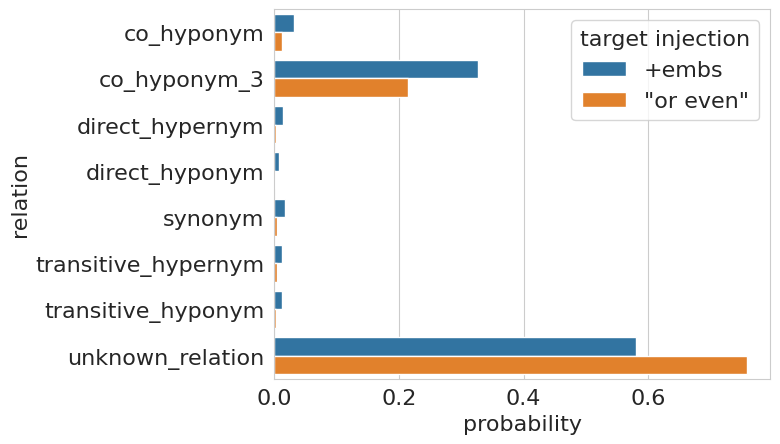

In [50]:
import matplotlib.pyplot as plt
import matplotlib
font = {'size' : 16}
matplotlib.rc('font', **font)

sns.barplot(plot_df.rename(columns={'model_name': 'target injection'}).sort_values(by='target injection', ascending=False), y='relation', x='probability', hue='target injection')
plt.savefig('wordnet relations.png', dpi=150, bbox_inches="tight")

In [8]:
print(df[df.lang == 'sl'].groupby(['word', 'gold_sense_id']).context.count())

word     gold_sense_id
beseda   bn:00069438n      3
         bn:00074033n     13
         bn:00081546n     13
         bn:00081547n      1
denar    bn:00055644n     26
         bn:00055645n      7
         bn:00055646n      1
država   bn:00023235n      8
         bn:00023236n     29
         bn:00074010n     13
hiša     bn:00014160n      1
         bn:00032892n      1
         bn:00044994n     42
mesto    bn:00010073n      3
         bn:00019321n      7
         bn:00062699n      1
         bn:00062700n      5
         bn:00062701n      1
         bn:00077773n     11
moč      bn:00035769n      3
         bn:00063940n     10
         bn:00074615n      4
         bn:00074616n      2
način    bn:00001965n      3
         bn:00033729n     18
         bn:00080724n      1
okolje   bn:00007786n      2
         bn:00031074n      6
         bn:00031075n     11
prostor  bn:00005516n      1
         bn:00030098n      1
         bn:00046665n      2
         bn:00068233n     10
         bn:00073039